In [2]:
# Step 1: Import packages, load dataset, and clean text

import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.decomposition import NMF

# Output folder
output_dir = Path("outputs_text_analysis")
output_dir.mkdir(exist_ok=True)

# Load dataset
DATA_PATH = Path("data/bitcoin_tweet.parquet")

print("Dataset exists:", DATA_PATH.exists())
print("Dataset size in MB:", round(DATA_PATH.stat().st_size / (1024 * 1024), 2))

df = pd.read_parquet(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

# Text column
TEXT_COL = "text"

# Final HD stopwords
custom_stopwords_hd = {
    # Twitter / platform noise
    "rt", "amp", "https", "http", "www", "com",
    "username", "user", "users", "tweet", "tweets", "twitter",
    "follow", "followers", "link", "join", "tips",
    
    # Domain words that are too obvious because all data is about Bitcoin/crypto
    "btc", "bitcoin", "crypto", "cryptocurrency",
    
    # Generic low-value words
    "just", "like", "time", "people", "don", "good", "going", "think",
    "know", "make", "need", "new", "really", "want", "way", "day",
    "today", "thing", "things", "let", "look", "still", "much",
    "many", "say", "said", "year", "years", "week", "weeks",
    "great", "right", "best", "big", "soon", "use", "better",
    
    # Spam/promotional/noisy terms found in previous outputs
    "seasonaltokens", "cryptomining", "cyclicalinvesting", "cyclicallnvesting",
    "betfurysuccess", "cashback", "rank", "play", "higher", "staking",
    "seriously", "doing"
}

stopwords_hd = set(ENGLISH_STOP_WORDS).union(custom_stopwords_hd)

def clean_text_hd(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"@\w+", " ", text)             # remove mentions
    text = re.sub(r"#", " ", text)                # remove hashtag symbol
    text = re.sub(r"[^a-z\s]", " ", text)         # keep letters only
    text = re.sub(r"\s+", " ", text).strip()      # remove extra spaces
    
    tokens = [
        word for word in text.split()
        if word not in stopwords_hd and len(word) > 2
    ]
    
    return " ".join(tokens)

# Apply cleaning
df["clean_text_hd"] = df[TEXT_COL].apply(clean_text_hd)

# Remove empty cleaned tweets
df_clean_hd = df[df["clean_text_hd"].str.len() > 2].copy()

print("Rows after HD cleaning:", len(df_clean_hd))

df_clean_hd[["text", "clean_text_hd"]].head(10)

Dataset exists: True
Dataset size in MB: 131.74
Dataset shape: (632179, 13)
Columns:
['user_name', 'user_created', 'user_followers', 'user_friends', 'user_verified', 'date', 'text', 'hashtags', 'mentions', 'account_age_days', 'age_bucket', 'url_count', 'text_clean']
Rows after HD cleaning: 627360


,text,clean_text_hd
16,@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - ...,amazing impressed project hopefully event comm...
24,@iamDonaldYusuf @yuzomausman @aproko_doctor No...,fud sub wan risk buy prices imo
25,I personally ignore weekend moves and chill wi...,personally ignore weekend moves chill family
31,Move Digital Energy Through Cyber Space. #Bitc...,digital energy cyber space
51,"1/2 End of shitcoin season, lasted even longer...",end shitcoin season lasted longer expected fro...
59,More traditional market content going on the T...,traditional market content tube content youtub...
61,Less than 10hours to save #Bitcoin weekly cand...,hours save weekly candle
87,@JasonPLowery Real Question?\n\nWouldn’t this ...,real question wouldn mean nations warfare long...
89,@JoshuaBarbin1 @danheld How do you get more de...,decentralized network tens thousands nodes cou...
110,#11MINUTES #BTC #CRYPTO\nThis project is a pro...,minutes project profitable project investors i...


In [3]:
# Step 2: Prepare for topic modelling

RANDOM_STATE = 42
TOPIC_SAMPLE_SIZE = 200000

if len(df_clean_hd) > TOPIC_SAMPLE_SIZE:
    topic_df = df_clean_hd.sample(n=TOPIC_SAMPLE_SIZE, random_state=RANDOM_STATE).copy()
else:
    topic_df = df_clean_hd.copy()

print("Total cleaned tweets:", len(df_clean_hd))
print("Rows used for topic modelling:", len(topic_df))

topic_df[["clean_text_hd"]].head(10)


Total cleaned tweets: 627360
Rows used for topic modelling: 200000


,clean_text_hd
2707681,human emotion market sentiment maddest witness
499782,initiate operation safe dailyclose
3120463,shouting lets goes
3498940,discovered ago
2566819,missed sol luna rocket train leaving inch catc...
909625,hodler send address
887944,investment properties change dependent systems...
1578396,muscky worldwide community try help launched t...
4047720,bought dip happy red friday
1366696,sense shorting mstr short short run won surprised


In [4]:
# Step 3: TF-IDF vectorisation

tfidf_vectorizer = TfidfVectorizer(
    stop_words=list(stopwords_hd),
    max_df=0.90,
    min_df=10,
    max_features=8000,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(topic_df["clean_text_hd"])

feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Number of tweets used:", tfidf_matrix.shape[0])
print("Number of terms/features used:", tfidf_matrix.shape[1])


TF-IDF matrix shape: (200000, 8000)
Number of tweets used: 200000
Number of terms/features used: 8000


Testing 3 topics...
Testing 4 topics...
Testing 5 topics...
Testing 6 topics...
Testing 7 topics...
Testing 8 topics...


,num_topics,reconstruction_error
0,3,443.031768
1,4,442.311596
2,5,441.626169
3,6,440.985601
4,7,440.365390
5,8,439.808190


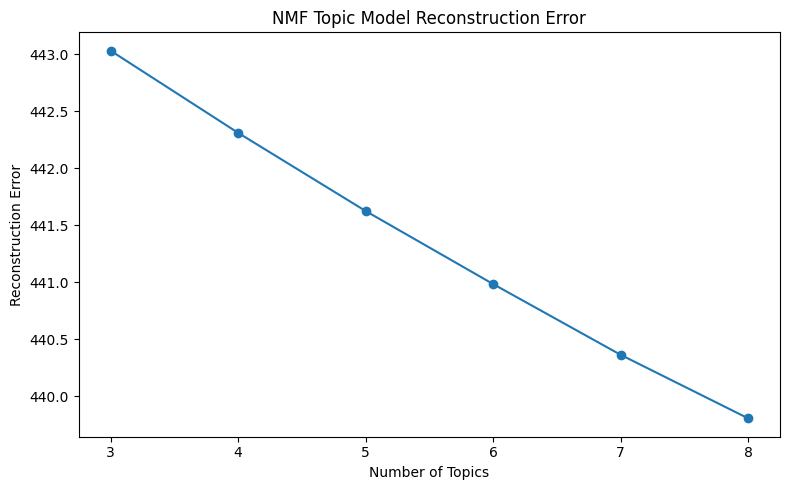

In [5]:
# Step 4: Compare different numbers of topics using NMF reconstruction error

topic_range = range(3, 9)
topic_scores = []

for n_topics in topic_range:
    print("Testing", n_topics, "topics...")
    
    nmf_model = NMF(
        n_components=n_topics,
        random_state=RANDOM_STATE,
        init="nndsvda",
        max_iter=400
    )
    
    nmf_model.fit(tfidf_matrix)
    
    topic_scores.append({
        "num_topics": n_topics,
        "reconstruction_error": nmf_model.reconstruction_err_
    })

topic_scores_df = pd.DataFrame(topic_scores)

display(topic_scores_df)

# Save result
topic_scores_df.to_csv(output_dir / "nmf_topic_number_scores.csv", index=False)

# Plot reconstruction error
plt.figure(figsize=(8, 5))
plt.plot(topic_scores_df["num_topics"], topic_scores_df["reconstruction_error"], marker="o")
plt.xlabel("Number of Topics")
plt.ylabel("Reconstruction Error")
plt.title("NMF Topic Model Reconstruction Error")
plt.tight_layout()
plt.savefig(output_dir / "nmf_reconstruction_error.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# Step 5: Build final NMF topic model

N_TOPICS = 5

final_nmf_model = NMF(
    n_components=N_TOPICS,
    random_state=RANDOM_STATE,
    init="nndsvda",
    max_iter=400
)

topic_matrix = final_nmf_model.fit_transform(tfidf_matrix)
topic_word_matrix = final_nmf_model.components_

# Assign each tweet to its strongest topic
topic_df["dominant_topic"] = topic_matrix.argmax(axis=1)
topic_df["topic_strength"] = topic_matrix.max(axis=1)

print("Topic counts:")
print(topic_df["dominant_topic"].value_counts().sort_index())

Topic counts:
dominant_topic
0     13410
1    139591
2     15647
3     17885
4     13467
Name: count, dtype: int64


In [7]:
# Step 6: Show top terms for each topic

def show_topics(model, feature_names, top_n=15):
    topic_results = []
    
    for topic_idx, topic_weights in enumerate(model.components_):
        top_indices = topic_weights.argsort()[::-1][:top_n]
        top_terms = [feature_names[i] for i in top_indices]
        
        topic_results.append({
            "topic": topic_idx,
            "top_terms": ", ".join(top_terms)
        })
    
    return pd.DataFrame(topic_results)

topics_hd = show_topics(final_nmf_model, feature_names, top_n=15)

display(topics_hd)

topics_hd.to_csv(output_dir / "nmf_topics_top_terms_hd.csv", index=False)

,topic,top_terms
0,0,"buy, dip, sell, buy dip, buy buy, hodl, sell b..."
1,1,"money, price, buying, long, world, gold, value..."
2,2,"project, future, team, bsc, bnb, hope, strong,..."
3,3,"eth, ethereum, bnb, doge, ada, xrp, eth bnb, s..."
4,4,"market, bear, bear market, bull, bull market, ..."


In [8]:
# Step 7: Show full topic terms clearly

pd.set_option("display.max_colwidth", None)
display(topics_hd)

,topic,top_terms
0,0,"buy, dip, sell, buy dip, buy buy, hodl, sell buy, buy sell, buy hodl, wait, hold, buy hold, did buy, did, money buy"
1,1,"money, price, buying, long, world, gold, value, fiat, bought, term, short, bullish, understand, inflation, does"
2,2,"project, future, team, bsc, bnb, hope, strong, success, project project, binance, successful, project future, blockchain, believe, support"
3,3,"eth, ethereum, bnb, doge, ada, xrp, eth bnb, sol, nft, ethereum eth, eth eth, eth ethereum, shib, dogecoin, bnb eth"
4,4,"market, bear, bear market, bull, bull market, cap, market cap, run, bull run, bullish, stock, stock market, end, ethereum, markets"


In [9]:
# Step 8: Add human-readable topic labels

topic_labels = {
    0: "Buying, selling and trading behaviour",
    1: "Bitcoin as money and store of value",
    2: "Crypto projects and future expectations",
    3: "Ethereum and altcoin discussion",
    4: "Market cycles and price movement"
}

topic_df["topic_label"] = topic_df["dominant_topic"].map(topic_labels)

topics_hd["topic_label"] = topics_hd["topic"].map(topic_labels)

display(topics_hd[["topic", "topic_label", "top_terms"]])

topics_hd[["topic", "topic_label", "top_terms"]].to_csv(
    output_dir / "nmf_topics_labelled_hd.csv",
    index=False
)

,topic,topic_label,top_terms
0,0,"Buying, selling and trading behaviour","buy, dip, sell, buy dip, buy buy, hodl, sell buy, buy sell, buy hodl, wait, hold, buy hold, did buy, did, money buy"
1,1,Bitcoin as money and store of value,"money, price, buying, long, world, gold, value, fiat, bought, term, short, bullish, understand, inflation, does"
2,2,Crypto projects and future expectations,"project, future, team, bsc, bnb, hope, strong, success, project project, binance, successful, project future, blockchain, believe, support"
3,3,Ethereum and altcoin discussion,"eth, ethereum, bnb, doge, ada, xrp, eth bnb, sol, nft, ethereum eth, eth eth, eth ethereum, shib, dogecoin, bnb eth"
4,4,Market cycles and price movement,"market, bear, bear market, bull, bull market, cap, market cap, run, bull run, bullish, stock, stock market, end, ethereum, markets"


,topic_label,tweet_count,percentage
0,Bitcoin as money and store of value,139591,69.80
1,Ethereum and altcoin discussion,17885,8.94
2,Crypto projects and future expectations,15647,7.82
3,Market cycles and price movement,13467,6.73
4,"Buying, selling and trading behaviour",13410,6.70


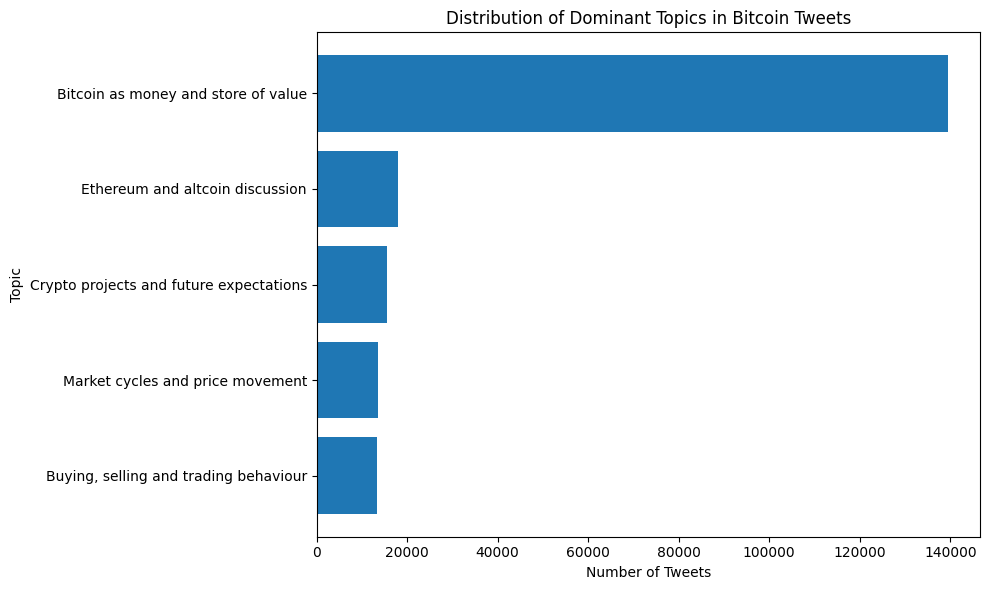

In [10]:
# Step 9: Topic distribution

topic_distribution = (
    topic_df["topic_label"]
    .value_counts()
    .rename_axis("topic_label")
    .reset_index(name="tweet_count")
)

topic_distribution["percentage"] = (
    topic_distribution["tweet_count"] / topic_distribution["tweet_count"].sum() * 100
).round(2)

display(topic_distribution)

topic_distribution.to_csv(output_dir / "topic_distribution_hd.csv", index=False)

plt.figure(figsize=(10, 6))
plt.barh(
    topic_distribution["topic_label"][::-1],
    topic_distribution["tweet_count"][::-1]
)
plt.xlabel("Number of Tweets")
plt.ylabel("Topic")
plt.title("Distribution of Dominant Topics in Bitcoin Tweets")
plt.tight_layout()
plt.savefig(output_dir / "topic_distribution_hd.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# Step 10: Representative tweets for each topic

representative_tweets = []

for topic_num in sorted(topic_df["dominant_topic"].unique()):
    subset = topic_df[topic_df["dominant_topic"] == topic_num].copy()
    subset = subset.sort_values("topic_strength", ascending=False).head(5)
    
    for _, row in subset.iterrows():
        representative_tweets.append({
            "topic": topic_num,
            "topic_label": row["topic_label"],
            "topic_strength": round(row["topic_strength"], 4),
            "original_text": row["text"],
            "clean_text": row["clean_text_hd"]
        })

representative_tweets_df = pd.DataFrame(representative_tweets)

display(representative_tweets_df)

representative_tweets_df.to_csv(
    output_dir / "representative_tweets_by_topic_hd.csv",
    index=False
)

,topic,topic_label,topic_strength,original_text,clean_text
0,0,"Buying, selling and trading behaviour",0.1478,I will buy 100.000 Btc more in 7 day. #Bitcoin,buy
1,0,"Buying, selling and trading behaviour",0.1478,@BIGTY_24 That’s more #Bitcoin I can buy,buy
2,0,"Buying, selling and trading behaviour",0.1478,"@Bitcoinomist Buy #btc around 20k, then keep it for 4-5 years",buy
3,0,"Buying, selling and trading behaviour",0.1478,If you could go back in time.\n\nWhat would you buy?\n#Bitcoin #Crypto,buy
4,0,"Buying, selling and trading behaviour",0.1478,@CryptoWhale you can buy time with #bitcoin,buy
5,1,Bitcoin as money and store of value,0.0715,@justin_Munford @CryptoA40672341 $wluna is best opportunity for make money . price going down because of #BTC,wluna opportunity money price
6,1,Bitcoin as money and store of value,0.0704,@KyleLDavies Too much money. Too few #BTC,money
7,1,Bitcoin as money and store of value,0.0704,"@saylor @IIICapital No way, \n#btc is more than a money",money
8,1,Bitcoin as money and store of value,0.0704,@TheMoonCarl whichever I make money 🤑 #Bitcoin,whichever money
9,1,Bitcoin as money and store of value,0.0704,@MartiniGuyYT But what if you don't have money to #BTC now?,money


In [12]:
# Step 11: Create final topic summary table

topic_summary = topic_distribution.copy()

# Add topic numbers
topic_number_lookup = (
    topic_df[["dominant_topic", "topic_label"]]
    .drop_duplicates()
    .rename(columns={"dominant_topic": "topic"})
)

topic_summary = topic_summary.merge(topic_number_lookup, on="topic_label", how="left")

# Reorder columns
topic_summary = topic_summary[["topic", "topic_label", "tweet_count", "percentage"]]

# Sort by topic number
topic_summary = topic_summary.sort_values("topic").reset_index(drop=True)

display(topic_summary)

topic_summary.to_csv(output_dir / "final_topic_summary_hd.csv", index=False)

,topic,topic_label,tweet_count,percentage
0,0,"Buying, selling and trading behaviour",13410,6.70
1,1,Bitcoin as money and store of value,139591,69.80
2,2,Crypto projects and future expectations,15647,7.82
3,3,Ethereum and altcoin discussion,17885,8.94
4,4,Market cycles and price movement,13467,6.73


In [13]:
pd.set_option("display.max_colwidth", None)
display(topics_hd[["topic", "topic_label", "top_terms"]])

,topic,topic_label,top_terms
0,0,"Buying, selling and trading behaviour","buy, dip, sell, buy dip, buy buy, hodl, sell buy, buy sell, buy hodl, wait, hold, buy hold, did buy, did, money buy"
1,1,Bitcoin as money and store of value,"money, price, buying, long, world, gold, value, fiat, bought, term, short, bullish, understand, inflation, does"
2,2,Crypto projects and future expectations,"project, future, team, bsc, bnb, hope, strong, success, project project, binance, successful, project future, blockchain, believe, support"
3,3,Ethereum and altcoin discussion,"eth, ethereum, bnb, doge, ada, xrp, eth bnb, sol, nft, ethereum eth, eth eth, eth ethereum, shib, dogecoin, bnb eth"
4,4,Market cycles and price movement,"market, bear, bear market, bull, bull market, cap, market cap, run, bull run, bullish, stock, stock market, end, ethereum, markets"


In [14]:
# Step 8: Final topic labels

topic_labels = {
    0: "Buying, selling and trading behaviour",
    1: "Bitcoin as money and store of value",
    2: "Crypto projects and future expectations",
    3: "Ethereum and altcoin discussion",
    4: "Market cycles and price movement"
}

topics_hd["topic_label"] = topics_hd["topic"].map(topic_labels)

display(topics_hd[["topic", "topic_label", "top_terms"]])

,topic,topic_label,top_terms
0,0,"Buying, selling and trading behaviour","buy, dip, sell, buy dip, buy buy, hodl, sell buy, buy sell, buy hodl, wait, hold, buy hold, did buy, did, money buy"
1,1,Bitcoin as money and store of value,"money, price, buying, long, world, gold, value, fiat, bought, term, short, bullish, understand, inflation, does"
2,2,Crypto projects and future expectations,"project, future, team, bsc, bnb, hope, strong, success, project project, binance, successful, project future, blockchain, believe, support"
3,3,Ethereum and altcoin discussion,"eth, ethereum, bnb, doge, ada, xrp, eth bnb, sol, nft, ethereum eth, eth eth, eth ethereum, shib, dogecoin, bnb eth"
4,4,Market cycles and price movement,"market, bear, bear market, bull, bull market, cap, market cap, run, bull run, bullish, stock, stock market, end, ethereum, markets"


In [15]:
# Step 9: Assign topics to the full cleaned dataset

# Transform full cleaned dataset using the same TF-IDF vectorizer
full_tfidf_matrix = tfidf_vectorizer.transform(df_clean_hd["clean_text_hd"])

# Apply the trained NMF model to the full dataset
full_topic_matrix = final_nmf_model.transform(full_tfidf_matrix)

# Assign dominant topic
df_clean_hd["dominant_topic"] = full_topic_matrix.argmax(axis=1)

# Raw NMF topic strength
df_clean_hd["topic_strength"] = full_topic_matrix.max(axis=1)

# Normalised confidence score
# This shows how strongly the tweet belongs to its dominant topic compared with other topics.
topic_strength_sum = full_topic_matrix.sum(axis=1)

df_clean_hd["topic_confidence"] = [
    max_score / total_score if total_score != 0 else 0
    for max_score, total_score in zip(full_topic_matrix.max(axis=1), topic_strength_sum)
]

# Add human-readable topic label
df_clean_hd["topic_label"] = df_clean_hd["dominant_topic"].map(topic_labels)

# Create text_clean column for group consistency
df_clean_hd["text_clean"] = df_clean_hd["clean_text_hd"]

print("Full dataset with topics created.")
print("Rows:", len(df_clean_hd))

display(
    df_clean_hd[
        ["text", "text_clean", "dominant_topic", "topic_label", "topic_strength", "topic_confidence"]
    ].head(10)
)

Full dataset with topics created.
Rows: 627360


,text,text_clean,dominant_topic,topic_label,topic_strength,topic_confidence
16,"@MexcResearch @MEXC_Fans @MEXC_Updates #BTC - 39000$\nThis is so amazing. I am impressed with this project, hopefully with this event and the community and especially this project can achieve success.\n@AlNahyanPrince1\n@apnahyan2\n@mita394",amazing impressed project hopefully event community especially project achieve success,2,Crypto projects and future expectations,0.072213,1.000000
24,@iamDonaldYusuf @yuzomausman @aproko_doctor Not now as there is fud of sub $30k #BTC ...people no wan risk buy at dz prices imo,fud sub wan risk buy prices imo,0,"Buying, selling and trading behaviour",0.027366,0.847898
25,I personally ignore weekend moves and chill with the family #BTC,personally ignore weekend moves chill family,1,Bitcoin as money and store of value,0.003063,0.500047
31,Move Digital Energy Through Cyber Space. #Bitcoin #BTC,digital energy cyber space,1,Bitcoin as money and store of value,0.006991,0.997873
51,"1/2 End of shitcoin season, lasted even longer than expected. Frog nation gone missing. Cronje out. ETH soon single digit gas price during weekends. BTC volumes are dead. We are now deep in 2018. Cycle is over. BTC plays the 30-45k range for months\n#cronje #frognation #BTC",end shitcoin season lasted longer expected frog nation gone missing cronje eth single digit gas price weekends volumes dead deep cycle plays range months cronje frognation,3,Ethereum and altcoin discussion,0.022690,0.572763
59,More traditional market content going on the Tube this week. \n\nMore #Crypto content going on @LearnCryptoUK YouTub channel \n\nMore #Crypto + #Stocks going on Patreon too...\n\n#BTC,traditional market content tube content youtub channel stocks patreon,4,Market cycles and price movement,0.037266,0.999653
61,Less than 10hours to save #Bitcoin weekly candle. #BTC,hours save weekly candle,1,Bitcoin as money and store of value,0.004956,0.687624
87,"@JasonPLowery Real Question?\n\nWouldn’t this mean that if everyone/nations were on #BTC, and warfare no longer had affective financial attack point, wouldn’t bad actors (I.e. Putin) &amp; conflicts, target people even more because they can’t affect the financial system?",real question wouldn mean nations warfare longer affective financial attack point wouldn bad actors putin conflicts target affect financial,1,Bitcoin as money and store of value,0.010599,0.905907
89,"@JoshuaBarbin1 @danheld How do you get more decentralized than #bitcoin network?\n\nTens of thousands of nodes in 100+ countries.\n\nAnd we have a saying: don’t trust, verify.\n\nI run my own node. Can view and query the entire #BTC ledger at any time. Can you do that with gold?",decentralized network tens thousands nodes countries saying trust verify run node view query entire ledger gold,1,Bitcoin as money and store of value,0.011004,0.825427
110,#11MINUTES #BTC #CRYPTO\nThis project is a profitable project for investors. I think investors can make a lot of profit if they invest in this project.,minutes project profitable project investors investors lot profit invest project,2,Crypto projects and future expectations,0.102631,0.986669


In [16]:
# Step 10: Full dataset topic distribution

full_topic_summary = (
    df_clean_hd["topic_label"]
    .value_counts()
    .rename_axis("topic_label")
    .reset_index(name="tweet_count")
)

full_topic_summary["percentage"] = (
    full_topic_summary["tweet_count"] / full_topic_summary["tweet_count"].sum() * 100
).round(2)

display(full_topic_summary)

full_topic_summary.to_csv(
    output_dir / "full_dataset_topic_summary_hd.csv",
    index=False
)

,topic_label,tweet_count,percentage
0,Bitcoin as money and store of value,437662,69.76
1,Ethereum and altcoin discussion,56299,8.97
2,Crypto projects and future expectations,49425,7.88
3,Market cycles and price movement,42232,6.73
4,"Buying, selling and trading behaviour",41742,6.65


In [17]:
# Step 11: Export enriched dataset for group integration

export_columns = [
    "user_name",
    "user_created",
    "user_followers",
    "user_friends",
    "user_verified",
    "date",
    "text",
    "text_clean",
    "hashtags",
    "mentions",
    "account_age_days",
    "dominant_topic",
    "topic_label",
    "topic_strength",
    "topic_confidence"
]

# Keep only columns that exist in the dataset
export_columns = [col for col in export_columns if col in df_clean_hd.columns]

bitcoin_tweet_with_topics = df_clean_hd[export_columns].copy()

output_file = Path("data/bitcoin_tweet_with_topics.parquet")

bitcoin_tweet_with_topics.to_parquet(output_file, index=False)

print("Export complete.")
print("Saved file:", output_file)
print("Rows exported:", len(bitcoin_tweet_with_topics))
print("Columns exported:")
print(bitcoin_tweet_with_topics.columns.tolist())

Export complete.
Saved file: data\bitcoin_tweet_with_topics.parquet
Rows exported: 627360
Columns exported:
['user_name', 'user_created', 'user_followers', 'user_friends', 'user_verified', 'date', 'text', 'text_clean', 'hashtags', 'mentions', 'account_age_days', 'dominant_topic', 'topic_label', 'topic_strength', 'topic_confidence']


NLTK not found. Installing nltk...


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\JENI\AppData\Roaming\nltk_data...


Packages ready.
df_clean_hd not found. Loading saved topic file instead...
Loaded file: data/bitcoin_tweet_with_topics.parquet
Dataset shape: (627360, 15)
Columns available:
['user_name', 'user_created', 'user_followers', 'user_friends', 'user_verified', 'date', 'text', 'text_clean', 'hashtags', 'mentions', 'account_age_days', 'dominant_topic', 'topic_label', 'topic_strength', 'topic_confidence']
vader_compound column not found. Calculating VADER sentiment now...
Using text column for VADER: text_clean
VADER sentiment calculated successfully.


,Topic,Topic Label,Average VADER Score,Dominant Sentiment,Number of Tweets,Positive Tweets,Neutral Tweets,Negative Tweets
0,0,"Buying, selling and trading behaviour",0.0660,Positive,41742,14426,17771,9545
1,1,Bitcoin as money and store of value,0.0874,Positive,437662,179084,146903,111675
2,2,Crypto projects and future expectations,0.4301,Positive,49425,35750,10005,3670
3,3,Ethereum and altcoin discussion,0.1053,Positive,56299,22242,22754,11303
4,4,Market cycles and price movement,0.0617,Positive,42232,16786,13334,12112


Saved table to: outputs\figure_5_4_average_sentiment_by_topic.csv


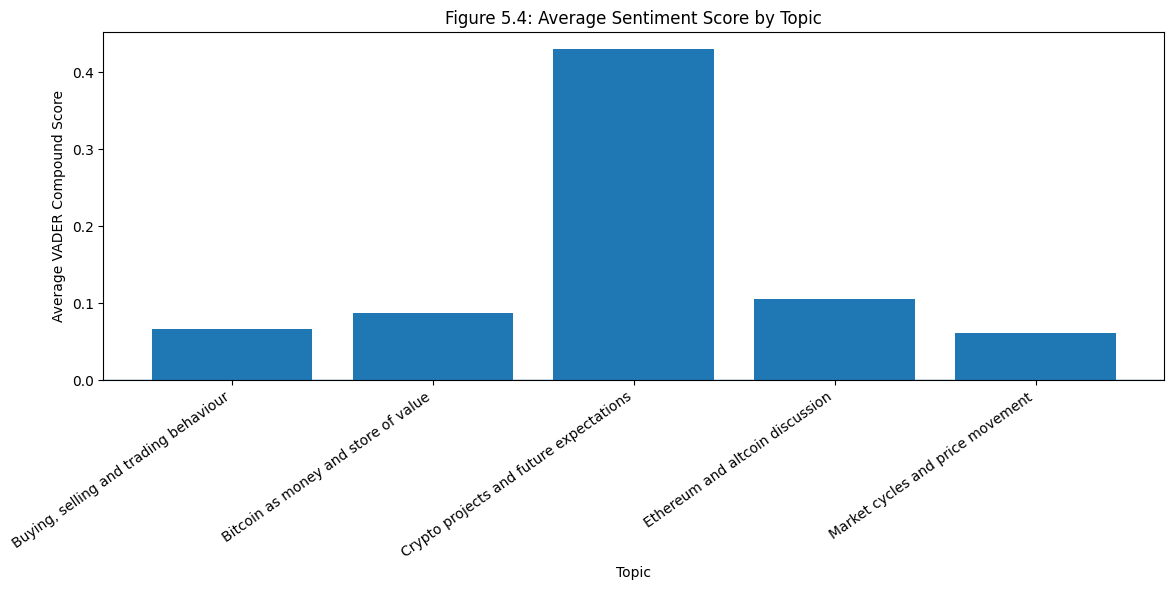

Saved chart to: outputs\figure_5_4_average_sentiment_by_topic.png
Saved updated dataset to: outputs\bitcoin_tweet_with_topics_and_vader.parquet


In [4]:
# ============================================================
# FIGURE 5.4 — AVERAGE VADER SENTIMENT SCORE BY TOPIC
# Add this as a NEW CELL at the END of 04_topic_modelling.ipynb
# ============================================================

# ------------------------------------------------------------
# 0. Install and import required packages
# ------------------------------------------------------------

import sys
import subprocess
from pathlib import Path

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import nltk
except ModuleNotFoundError:
    print("NLTK not found. Installing nltk...")
    install_package("nltk")
    import nltk

import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("vader_lexicon")

print("Packages ready.")


# ------------------------------------------------------------
# 1. Load the topic modelling dataset
# ------------------------------------------------------------

try:
    df_topic = df_clean_hd.copy()
    print("Using existing dataframe: df_clean_hd")
except NameError:
    print("df_clean_hd not found. Loading saved topic file instead...")

    possible_paths = [
        "data/bitcoin_tweet_with_topics.parquet",
        "outputs/bitcoin_tweet_with_topics.parquet",
        "bitcoin_tweet_with_topics.parquet"
    ]

    df_topic = None

    for path in possible_paths:
        if Path(path).exists():
            df_topic = pd.read_parquet(path)
            print(f"Loaded file: {path}")
            break

    if df_topic is None:
        raise FileNotFoundError(
            "Could not find bitcoin_tweet_with_topics.parquet. "
            "Make sure you run the topic modelling notebook first and export the file."
        )

print("Dataset shape:", df_topic.shape)
print("Columns available:")
print(df_topic.columns.tolist())


# ------------------------------------------------------------
# 2. Check required topic columns
# ------------------------------------------------------------

if "dominant_topic" not in df_topic.columns:
    raise ValueError(
        "Column 'dominant_topic' is missing. "
        "Run the topic modelling code first."
    )

if "topic_label" not in df_topic.columns:
    raise ValueError(
        "Column 'topic_label' is missing. "
        "Run the topic labelling code first."
    )


# ------------------------------------------------------------
# 3. Create VADER compound score if missing
# ------------------------------------------------------------

if "vader_compound" not in df_topic.columns:
    print("vader_compound column not found. Calculating VADER sentiment now...")

    sia = SentimentIntensityAnalyzer()

    # Select correct text column
    if "clean_text" in df_topic.columns:
        text_col = "clean_text"
    elif "cleaned_text" in df_topic.columns:
        text_col = "cleaned_text"
    elif "text_clean" in df_topic.columns:
        text_col = "text_clean"
    elif "text" in df_topic.columns:
        text_col = "text"
    else:
        raise ValueError(
            "No usable text column found. Expected one of: "
            "'clean_text', 'cleaned_text', 'text_clean', or 'text'."
        )

    print(f"Using text column for VADER: {text_col}")

    df_topic["vader_compound"] = df_topic[text_col].fillna("").astype(str).apply(
        lambda x: sia.polarity_scores(x)["compound"]
    )

    print("VADER sentiment calculated successfully.")
else:
    print("Using existing vader_compound column.")


# ------------------------------------------------------------
# 4. Create sentiment labels
# ------------------------------------------------------------

def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df_topic["vader_sentiment_label"] = df_topic["vader_compound"].apply(classify_sentiment)


# ------------------------------------------------------------
# 5. Calculate average sentiment by topic
# ------------------------------------------------------------

topic_sentiment = (
    df_topic
    .groupby(["dominant_topic", "topic_label"])
    .agg(
        average_vader_score=("vader_compound", "mean"),
        number_of_tweets=("vader_compound", "count"),
        positive_tweets=("vader_sentiment_label", lambda x: (x == "Positive").sum()),
        neutral_tweets=("vader_sentiment_label", lambda x: (x == "Neutral").sum()),
        negative_tweets=("vader_sentiment_label", lambda x: (x == "Negative").sum())
    )
    .reset_index()
)

topic_sentiment["dominant_sentiment"] = topic_sentiment["average_vader_score"].apply(classify_sentiment)

topic_sentiment["average_vader_score"] = topic_sentiment["average_vader_score"].round(4)

topic_sentiment_report = topic_sentiment.rename(columns={
    "dominant_topic": "Topic",
    "topic_label": "Topic Label",
    "average_vader_score": "Average VADER Score",
    "dominant_sentiment": "Dominant Sentiment",
    "number_of_tweets": "Number of Tweets",
    "positive_tweets": "Positive Tweets",
    "neutral_tweets": "Neutral Tweets",
    "negative_tweets": "Negative Tweets"
})

topic_sentiment_report = topic_sentiment_report[
    [
        "Topic",
        "Topic Label",
        "Average VADER Score",
        "Dominant Sentiment",
        "Number of Tweets",
        "Positive Tweets",
        "Neutral Tweets",
        "Negative Tweets"
    ]
]

display(topic_sentiment_report)


# ------------------------------------------------------------
# 6. Save table for report
# ------------------------------------------------------------

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

csv_path = output_dir / "figure_5_4_average_sentiment_by_topic.csv"

topic_sentiment_report.to_csv(csv_path, index=False)

print(f"Saved table to: {csv_path}")


# ------------------------------------------------------------
# 7. Create Figure 5.4 bar chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    topic_sentiment_report["Topic Label"],
    topic_sentiment_report["Average VADER Score"]
)

plt.xlabel("Topic")
plt.ylabel("Average VADER Compound Score")
plt.title("Figure 5.4: Average Sentiment Score by Topic")
plt.xticks(rotation=35, ha="right")
plt.axhline(0, linewidth=1)
plt.tight_layout()

chart_path = output_dir / "figure_5_4_average_sentiment_by_topic.png"

plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {chart_path}")


# ------------------------------------------------------------
# 8. Optional: Save updated dataset with VADER scores
# ------------------------------------------------------------

updated_path = output_dir / "bitcoin_tweet_with_topics_and_vader.parquet"

df_topic.to_parquet(updated_path, index=False)

print(f"Saved updated dataset to: {updated_path}")